In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 2: Optimising Noisy Models

This corresponds to trying to optimise an unknown machine learning model. However, the initialization of the model is very important, meaning your observations will be very noisy, and the problem might have a lot of local optima! You are trying to make the model’s log-likelihood as large as possible.

**Problem: Optimising Noisy Models**

**What does this mean?**

**Unknown Model:**
You are trying to optimize (find the best input for) a function that you cannot see or write down explicitly. This is common in machine learning when you want to tune hyperparameters or inputs to maximize some performance metric.

**Noisy Observations:**
Every time you try an input, the output (observation) you get is noisy—it has random error. This could be due to randomness in the model, data, or measurement process.

**Many Local Optima:**
The function you are optimizing is not smooth and simple; it has many peaks and valleys (local optima). This means it’s easy to get stuck in a “good” but not “best” solution.

**Log-Likelihood Maximization:**
In machine learning, the log-likelihood is a measure of how well your model explains the data. Maximizing it means you want to find the input (or hyperparameters) that make your model fit the data as well as possible.

**Real-World Analogy**
Imagine you are tuning the settings of a complicated machine (like a car engine) to get the best performance.

Every time you change the settings and measure the output, the result is a bit random (noisy).
Sometimes, a setting gives you a good result, but there might be an even better setting elsewhere.
Your goal is to find the settings that give you the best average performance, not just a lucky high reading.

In [23]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [24]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.66579958, 0.12396913],
        [0.87779099, 0.7786275 ],
        [0.14269907, 0.34900513],
        [0.84527543, 0.71112027],
        [0.45464714, 0.29045518],
        [0.57771284, 0.77197318],
        [0.43816606, 0.68501826],
        [0.34174959, 0.02869772],
        [0.33864816, 0.21386725],
        [0.70263656, 0.9265642 ]]),
 10)

In [25]:
#new_query_1 =  np.array([1.00000e-06, 9.99999e-01])
#new_query_2 =  np.array([0.999999, 0.999999])
#new_query_3 =  np.array([1.e-06, 1.e-06])
#new_query_4 =  np.array([9.99999e-01, 1.00000e-06])
#new_query_5 =  np.array([6.76767e-01, 1.00000e-06])
#X = np.vstack([X, new_query_1, new_query_2, new_query_3, new_query_4, new_query_5])
#X

queries = queries_for_function(2)
X = np.vstack([X, queries])
X, len(X)

(array([[6.65799580e-01, 1.23969128e-01],
        [8.77790989e-01, 7.78627501e-01],
        [1.42699074e-01, 3.49005131e-01],
        [8.45275429e-01, 7.11120267e-01],
        [4.54647141e-01, 2.90455180e-01],
        [5.77712844e-01, 7.71973184e-01],
        [4.38166062e-01, 6.85018257e-01],
        [3.41749593e-01, 2.86977198e-02],
        [3.38648157e-01, 2.13867246e-01],
        [7.02636557e-01, 9.26564198e-01],
        [5.65656000e-01, 9.99999000e-01],
        [6.66666000e-01, 2.82829000e-01],
        [8.18181000e-01, 1.91920000e-01],
        [5.55555000e-01, 1.00000000e-06],
        [5.75757000e-01, 4.64647000e-01],
        [1.72728000e-01, 6.25087000e-01],
        [3.53170000e-02, 1.43501000e-01],
        [8.66822000e-01, 4.67368000e-01],
        [1.19428000e-01, 9.50321000e-01],
        [2.63265000e-01, 6.51415000e-01],
        [9.99999000e-01, 5.25252000e-01]]),
 21)

In [26]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522]),
 10)

In [27]:
#y = np.append(y, [0.0, 1.517648729565899e-192, 2.31546114628124e-248, 0.0, 5.4713831123687026e-170], axis=0)
#y

observations = observations_for_function(2)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522,
         0.00383348,  0.45575856,  0.16684519, -0.01344612,  0.1062046 ,
         0.0482295 , -0.02461208,  0.74906492, -0.00791856, -0.06233066,
        -0.02172702]),
 21)

In [28]:
best_idx = np.argmax(y)
print("Best input so far:", X[best_idx])
print("Best log-likelihood so far:", y[best_idx])

Best input so far: [0.866822 0.467368]
Best log-likelihood so far: 0.7490649223844393


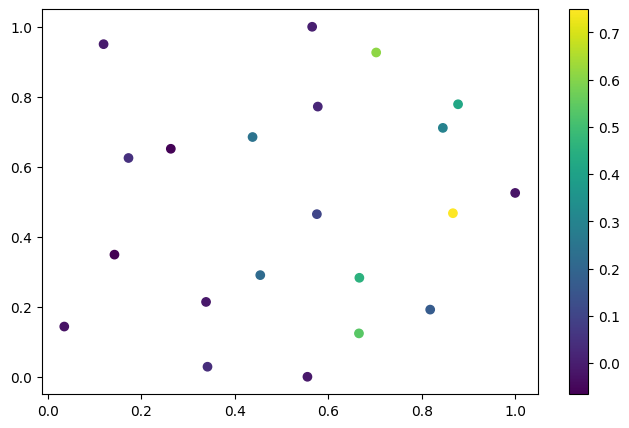

In [29]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

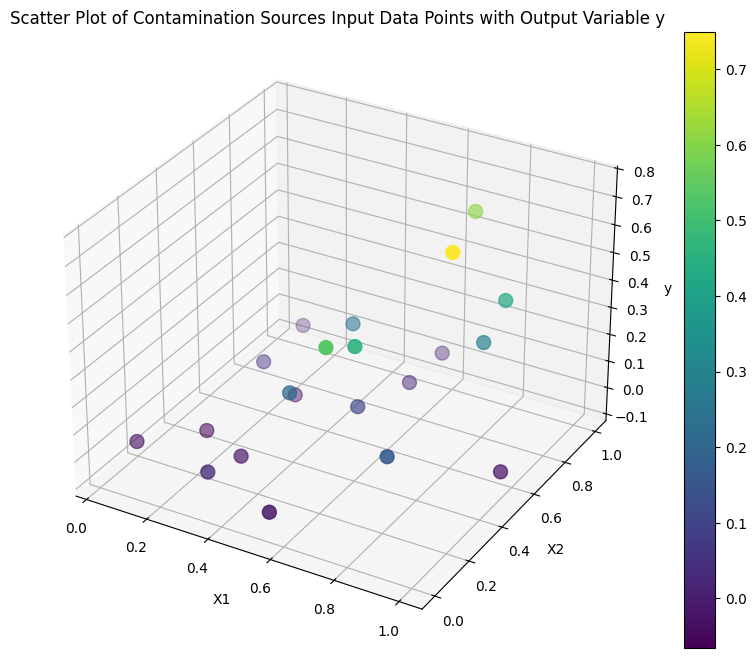

In [30]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


In [31]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

In [32]:
def query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)

    
    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,2)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return x, y_pred

In [33]:
def next_query_with_default_kernel(X, y, x1_grid, x2_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

Exploration: Explore the whole space with defalut RBF Kernel

In [34]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y,x1_grid, x2_grid)

Random Query: 0.243467-0.394302


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 7.520976614265185
Index of maximum acquisition function value:  9900


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.474748-0.060607)
Predicted Value at (0.474748-0.060607) is 0.7591017790550503
Index of maximum acquisition function value:  647


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.212122)
Predicted Value at (0.000001-0.212122) is 1.6385439988836294
Index of maximum acquisition function value:  2100


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 7.520976614265185
Index of maximum acquisition function value:  9900


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.9999

Exploitation: Exploit around [8.66822000e-01, 4.67368000e-01]

In [35]:
x1_grid = np.linspace(0.75, 0.85, 100)
x2_grid = np.linspace(0.40, 0.50, 100)
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y,x1_grid, x2_grid)

Random Query: 0.205132-0.418877


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.7962903294988797
Index of maximum acquisition function value:  99


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.833838-0.400000)
Predicted Value at (0.833838-0.400000) is 0.7512014081096249
Index of maximum acquisition function value:  83


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.750000-0.400000)
Predicted Value at (0.750000-0.400000) is 0.43160094131051085
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.7962903294988797
Index of maximum acquisition function value:  99


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) i

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize

In [36]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Create the grid for predictions
    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 2)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}")
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))

    return x, y_pred

In [37]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)

# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, x1_grid, x2_grid, 
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=100,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, x1_grid, x2_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.979797)
Predicted Value at (0.858585-0.979797) is 0.27948368227086573
Index of maximum acquisition function value:  9785


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999)
Predicted Value at (0.999999-0.999999) is 0.2539228155206537
Index of maximum acquisition function value:  9999


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.7546961620205062
Index of maximum acquisition function value:  4482


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.595959)
Predicted Value at (0.999999-0.595959) is 0.296364480231551
Index of maximum acquisition function value:  5999


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.40181297797546794
Index of maximum acquisition function value:  99


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The

...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.3963930783497822
Index of maximum acquisition function value:  99


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.7553988293221144
Index of maximum acquisition function value:  4482


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.6712198762900957
Index of maximum acquisition function value:  4686


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.7553988291513514
Index of maximum acquisition function value:  4482


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.7553988311722132
Index of maximum acquisition function value:  4482


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.7553988327226756
Index of maximum acquisition function value:  4482


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.828282-0.444445)
Predicted Value at (0.828282-0.444445) is 0.755398833556245
Index of maximum acquisition function valu

(array([[0.85858514, 0.46464654]]), array([0.76789155]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [38]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.464647)
Predicted Value at (0.858585-0.464647) is 0.7678915477694962
Index of maximum acquisition function value:  4685


(array([[0.85858514, 0.46464654]]), array([0.76789155]))

Exploitation: Expoit for Radiation Source 1 around [8.66822000e-01, 4.67368000e-01]

In [39]:
x1_grid = np.linspace(0.75, 0.85, 100)
x2_grid = np.linspace(0.40, 0.50, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.461616)
Predicted Value at (0.850000-0.461616) is 0.7812798274786258
Index of maximum acquisition function value:  6199


(array([[0.85      , 0.46161616]]), array([0.78127983]))

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization

In [40]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, x1_grid, x2_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=100
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, x1_grid, x2_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.466667)
Predicted Value at (0.850000-0.466667) is 0.5138628008470654
Index of maximum acquisition function value:  6699
| 1         | -0.5139   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.462626)
Predicted Value at (0.850000-0.462626) is 0.5407501170250122
Index of maximum acquisition function value:  6299
| 2         | -0.5408   | 0.2323    | 2.732     | 1.803     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.3139511772250943
Index of maximum acquisition function value:  99
| 3         | -0.314    | 3.33      | 1.425     | 0.5455    | 0.1916    | 0.03042   | 7.871     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.799495-0.400000)
Predicted Value at (0.799495-0.400000) is 0.3240506771025288
Index of maximum acquisition function value:  49
| 4         | -0.3241   | 1.728     | 1.582     | 1.836     | 0.1481    | 0.02921   | 5.495     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximiz

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optim



UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.500000)
Predicted Value at (0.850000-0.500000) is 0.27494927111310646
Index of maximum acquisition function value:  9999
| 7         | -0.2749   | 0.4968    | 2.425     | 2.222     | 0.1649    | 0.06338   | 13.27     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.2949438597496614
Index of maximum acquisition function value:  99
| 8         | -0.2949   | 0.8414    | 2.985     | 0.6417    | 0.704     | 0.04956   | 4.315     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.32643480708833417
Index of maximum acquisition function value:  99
| 9         | -0.3264   | 3.158     | 2.071     | 2.684     | 0.4628    | 0.04225   | 9.807     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.85000

...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.325833447674011
Index of maximum acquisition function value:  99
| 97        | -0.3258   | 1.583     | 2.203     | 2.606     | 0.9149    | 0.04891   | 2.704     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.33145700008700363
Index of maximum acquisition function value:  99
| 98        | -0.3315   | 0.4581    | 2.971     | 2.873     | 0.6696    | 0.01749   | 8.389     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.821717-0.469697)
Predicted Value at (0.821717-0.469697) is 0.2893496117640954
Index of maximum acquisition function value:  6971
| 99        | -0.2893   | 3.672     | 1.515     | 2.434     | 0.7942    | 0.04866   | 4.177     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.400000)
Predicted Value at (0.850000-0.400000) is 0.27903857836535073
Index of maximum acquisition function value:  99
| 100       | -0.279    | 0.8696    | 2.891     | 1.309     | 0.4872    | 0.06663   | 11.91     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.466667)
Predicted Value at (0.850000-0.466667) is 0.5193652109721785
Index of maximum acquisition function value:  6699
| 101       | -0.5194   | 1.229     | 2.195     | 2.256     | 0.417     | 0.01409   | 0.1337    |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.40000

(array([[0.85      , 0.46767677]]), array([0.07837676]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [41]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.10906171618979457
Index of maximum acquisition function value:  4686


(array([[0.86868613, 0.46464654]]), array([0.10906172]))

Exploitation: Expoit for Radiation Source 1 around [8.66822000e-01, 4.67368000e-01]

In [42]:
x1_grid = np.linspace(0.75, 0.85, 100)
x2_grid = np.linspace(0.40, 0.50, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.850000-0.467677)
Predicted Value at (0.850000-0.467677) is 0.07837675592295423
Index of maximum acquisition function value:  6799


(array([[0.85      , 0.46767677]]), array([0.07837676]))